In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df_original = pd.read_parquet('../Imdb_Movie_Dataset.parquet')
print("Dados carregados com sucesso para o teste de Regressão Logística!")

Dados carregados com sucesso para o teste de Regressão Logística!


In [6]:
df = df_original.copy()

cond_nota = df['vote_average'] >= 6.8
cond_vmin = df['vote_count'] >= 20
cond_vmax = df['vote_count'] <= 3000
df['sucesso_nicho'] = (cond_nota & cond_vmin & cond_vmax).astype(int)

df['release_year'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce').dt.year
df['genres_limpo'] = df['genres'].astype(str).str.replace(r'[\(\)\[\]\']', '', regex=True).str.replace(' ', '')
df_genres = df['genres_limpo'].str.get_dummies(sep=',').add_prefix('genero_')

top_idiomas = df['original_language'].value_counts().head(5).index
df['idioma_agrupado'] = df['original_language'].where(df['original_language'].isin(top_idiomas), 'outros')
df_idiomas = pd.get_dummies(df['idioma_agrupado'], prefix='idioma', dtype=int)

pistas_numericas = df[['runtime', 'revenue', 'release_year']].fillna(0)
X = pd.concat([pistas_numericas, df_genres, df_idiomas], axis=1)
y = df['sucesso_nicho']

print(f"Total de filmes: {len(X)} | Total de Sucessos de Nicho: {y.sum()}")

Total de filmes: 951555 | Total de Sucessos de Nicho: 14542


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Dados padronizados e prontos para o treinamento linear.")

Dados padronizados e prontos para o treinamento linear.


=== RESULTADOS DO MODELO ===
                  precision    recall  f1-score   support

     Filme Comum       1.00      0.77      0.87    187326
Sucesso de Nicho       0.06      0.86      0.11      2985

        accuracy                           0.77    190311
       macro avg       0.53      0.82      0.49    190311
    weighted avg       0.98      0.77      0.86    190311



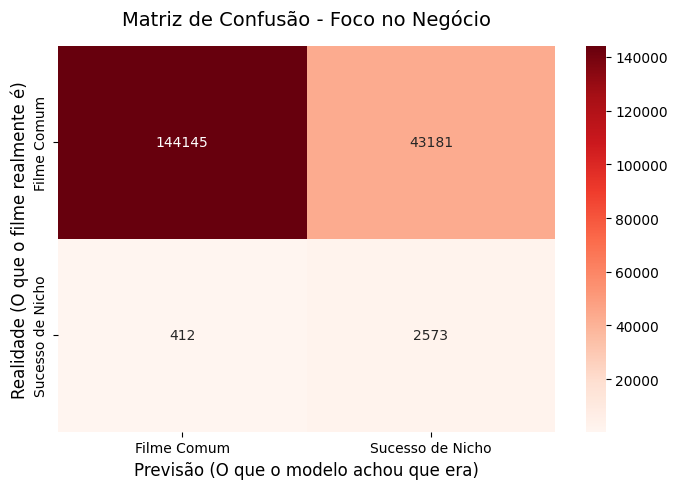

In [8]:
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

previsoes_lr = modelo_lr.predict(X_test_scaled)

nomes_das_classes = ['Filme Comum', 'Sucesso de Nicho']

print("=== RESULTADOS DO MODELO ===")
print(classification_report(y_test, previsoes_lr, target_names=nomes_das_classes))

plt.figure(figsize=(7,5))

sns.heatmap(
    confusion_matrix(y_test, previsoes_lr), 
    annot=True, 
    fmt='d', 
    cmap='Reds', 
    xticklabels=nomes_das_classes, 
    yticklabels=nomes_das_classes
)

plt.title('Matriz de Confusão - Foco no Negócio', fontsize=14, pad=15)
plt.ylabel('Realidade (O que o filme realmente é)', fontsize=12)
plt.xlabel('Previsão (O que o modelo achou que era)', fontsize=12)

plt.tight_layout()
plt.show()